<a href="https://colab.research.google.com/github/Serigne-Badiane/ECE-ARENA/blob/main/Projet_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Big Data Processing Project

##Chargement, nettoyage et préparation des données

In [ ]:
import pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, udf
from pyspark.sql.types import *
import json
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

# Crée une session Spark
spark = SparkSession.builder.appName("MovieRecommendation").getOrCreate()

# Construction des chemins complets pour chaque fichier CSV
movies_path = os.path.join(path, "movies_metadata.csv")
credits_path = os.path.join(path, "credits.csv")
keywords_path = os.path.join(path, "keywords.csv")
ratings_path = os.path.join(path, "ratings.csv")

# Chargement des datasets
movies_df = spark.read.option("header", True).option("inferSchema", True).csv(movies_path)
credits_df = spark.read.option("header", True).option("inferSchema", True).csv(credits_path)
keywords_df = spark.read.option("header", True).option("inferSchema", True).csv(keywords_path)
ratings_df = spark.read.option("header", True).option("inferSchema", True).csv(ratings_path)

# Preview
movies_df.show(5)
credits_df.show(5)
keywords_df.show(5)
ratings_df.show(5)


100%|██████████| 228M/228M [00:04<00:00, 53.8MB/s]

Extracting files...


+-----+---------------------+--------+--------------------+--------------------+-----+---------+-----------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------+--------------------+--------------------+--------+--------------------+-----------------+
|adult|belongs_to_collection|  budget|              genres|            homepage|   id|  imdb_id|original_language|      original_title|            overview|popularity|         poster_path|production_companies|production_countries|        release_date|             revenue|             runtime|    spoken_languages|  status|             tagline|               title|   video|        vote_average|       vote_count|
+-----+---------------------+--------+--------------------+--------------------+-----+---------+-----------------+--------------------+--------------------+----------+-----

In [ ]:
from pyspark.sql.functions import udf, to_date
from pyspark.sql.types import ArrayType, StringType
from ast import literal_eval

# UDF pour parser les champs JSON (comme les genres ou keywords)
def extract_names(json_str):
    try:
        return [x['name'] for x in literal_eval(json_str)]
    except:
        return []

extract_names_udf = udf(extract_names, ArrayType(StringType()))

# Parser les genres
movies_df = movies_df.withColumn("genres_parsed", extract_names_udf(col("genres")))

# Convertir release_date en date
movies_df = movies_df.withColumn("release_date", to_date("release_date", "yyyy-MM-dd"))

# Cast des colonnes numériques
movies_df = movies_df.withColumn("budget", col("budget").cast("float")) \
                     .withColumn("revenue", col("revenue").cast("float")) \
                     .withColumn("runtime", col("runtime").cast("float")) \
                     .withColumn("vote_average", col("vote_average").cast("float")) \
                     .withColumn("vote_count", col("vote_count").cast("int"))

# Nettoyage : suppression des films sans id ou sans revenue ou budget
movies_df = movies_df.filter((col("id").isNotNull()) & (col("revenue") > 0) & (col("budget") > 0))


In [ ]:
# Parser keywords
keywords_df = keywords_df.withColumn("keywords_parsed", extract_names_udf(col("keywords")))

# Convertir les IDs en int dans les 3 datasets
from pyspark.sql.functions import col
keywords_df = keywords_df.withColumn("id", col("id").cast("int"))
credits_df = credits_df.withColumn("id", col("id").cast("int"))
movies_df = movies_df.withColumn("id", col("id").cast("int"))


In [ ]:
# On joint les datasets sur la colonne id (film ID)
movies_full_df = movies_df \
    .join(credits_df, on="id", how="left") \
    .join(keywords_df.select("id", "keywords_parsed"), on="id", how="left")

# Vérification
movies_full_df.select("title", "genres_parsed", "keywords_parsed", "cast", "crew").show(3, truncate=100)


+------------+-----------------------------+---------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|       title|                genres_parsed|                                                                              keywords_parsed|                                                                                                cast|                                                                                                crew|
+------------+-----------------------------+---------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------

##Analyse

In [ ]:
# Statistiques descriptives de base
movies_full_df.select("budget", "revenue", "runtime", "vote_average", "vote_count").describe().show()


+-------+--------------------+--------------------+------------------+------------------+------------------+
|summary|              budget|             revenue|           runtime|      vote_average|        vote_count|
+-------+--------------------+--------------------+------------------+------------------+------------------+
|  count|                5052|                5052|              5003|              5001|              5002|
|   mean|3.0850081491144743E7| 8.919073688931131E7|110.02838297021786| 6.266026794803164| 722.7898840463814|
| stddev| 4.012039975736412E7|1.6725924450428164E8|22.056785649916517|0.9328277441329824|1227.6936831627402|
|    min|            0.042157|              1.0E-6|               0.0|               0.0|                 0|
|    max|               3.8E8|        2.78796518E9|             338.0|               9.1|             12269|
+-------+--------------------+--------------------+------------------+------------------+------------------+



+--------------------+------+------------+
|               title|budget|     revenue|
+--------------------+------+------------+
|Pirates of the Ca...| 3.8E8|1.04571379E9|
|Pirates of the Ca...| 3.0E8|      9.61E8|
|Avengers: Age of ...| 2.8E8|1.40540365E9|
|    Superman Returns| 2.7E8|3.91081184E8|
|             Tangled| 2.6E8| 5.9179494E8|
+--------------------+------+------------+
only showing top 5 rows

+------------+--------+-------+
|       title|  budget|revenue|
+------------+--------+-------+
|        NULL|0.118509|    2.0|
|        NULL|3.000275|   41.0|
|        NULL|0.244887|    5.0|
|        NULL|0.058367|    1.0|
|East of Eden|     1.0|    5.0|
+------------+--------+-------+
only showing top 5 rows



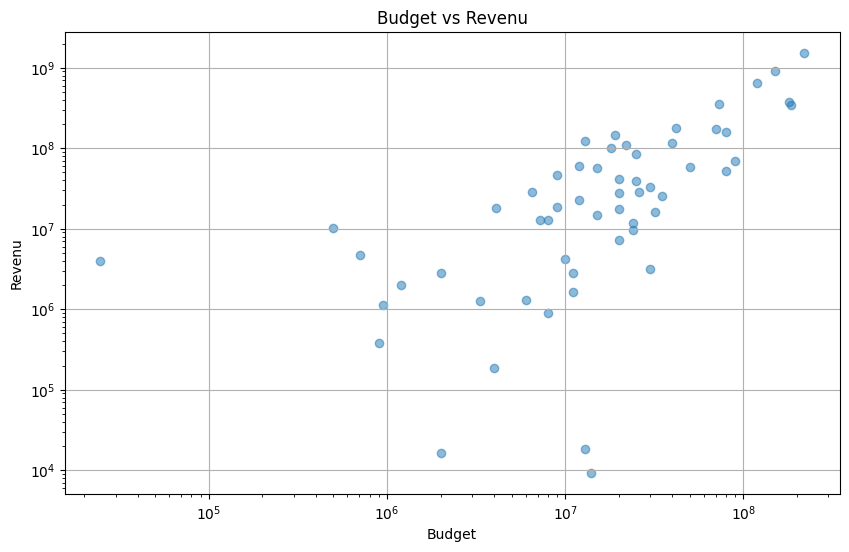

In [ ]:
import matplotlib.pyplot as plt

# Films avec un budget anormalement élevé
movies_full_df.orderBy(col("budget").desc()).select("title", "budget", "revenue").show(5)

# Films avec un revenu très bas (mais budget non nul)
movies_full_df.filter(col("revenue") < 1000).select("title", "budget", "revenue").show(5)

sample_df = movies_full_df \
    .filter((col("budget") > 0) & (col("revenue") > 0)) \
    .select("budget", "revenue") \
    .sample(fraction=0.01, seed=42) \
    .toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(sample_df['budget'], sample_df['revenue'], alpha=0.5)
plt.title("Budget vs Revenu")
plt.xlabel("Budget")
plt.ylabel("Revenu")
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()



+----+-----+
|year|count|
+----+-----+
|NULL|   48|
|1915|    2|
|1916|    1|
|1918|    2|
|1921|    1|
|1922|    1|
|1924|    1|
|1925|    4|
|1926|    2|
|1927|    2|
+----+-----+
only showing top 10 rows



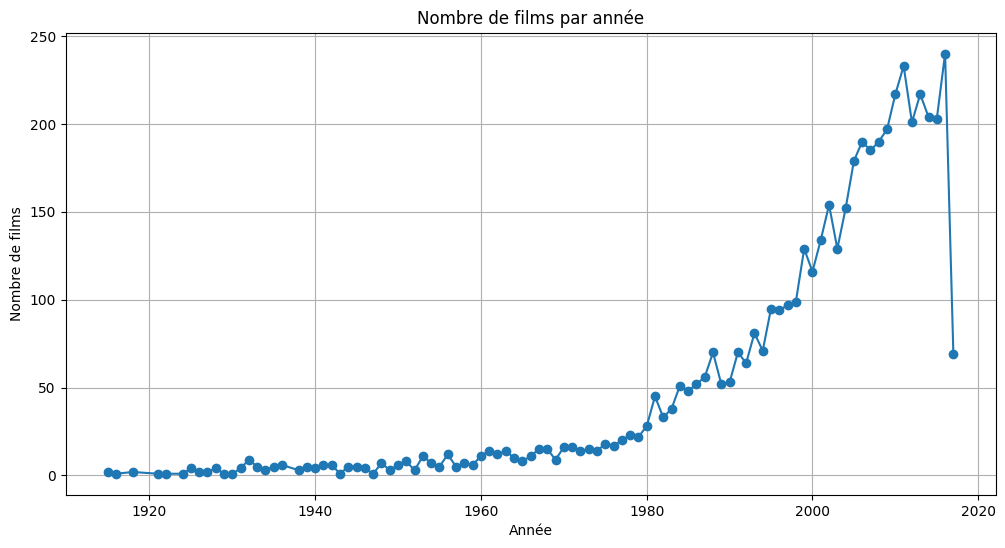

In [ ]:
from pyspark.sql.functions import year

movies_by_year = movies_full_df.withColumn("year", year("release_date")) \
    .groupBy("year").count().orderBy("year")

movies_by_year.show(10)

import matplotlib.pyplot as plt

# Reprendre les données groupées par année (déjà préparées dans Spark)
movies_by_year_pd = movies_by_year.dropna().toPandas()

plt.figure(figsize=(12, 6))
plt.plot(movies_by_year_pd['year'], movies_by_year_pd['count'], marker='o')
plt.title("Nombre de films par année")
plt.xlabel("Année")
plt.ylabel("Nombre de films")
plt.grid(True)
plt.show()


In [ ]:
from pyspark.sql.functions import explode

# On "explose" la liste des genres
genre_df = movies_full_df.withColumn("genre", explode("genres_parsed")) \
                         .groupBy("genre").count().orderBy(col("count").desc())

genre_df.show()


+---------------+-----+
|          genre|count|
+---------------+-----+
|          Drama| 2436|
|         Comedy| 1699|
|       Thriller| 1443|
|         Action| 1324|
|        Romance|  971|
|      Adventure|  902|
|          Crime|  801|
|Science Fiction|  582|
|         Horror|  560|
|         Family|  499|
|        Fantasy|  479|
|        Mystery|  424|
|      Animation|  270|
|        History|  224|
|            War|  194|
|          Music|  173|
|        Western|   85|
|    Documentary|   52|
|        Foreign|   32|
|       TV Movie|    1|
+---------------+-----+



##Nettoyage

In [ ]:
# Supprimer les lignes où le titre ou la date de sortie est manquant
movies_clean_df = movies_full_df.filter(
    (col("title").isNotNull()) &
    (col("release_date").isNotNull())
)


In [ ]:
# Garder uniquement les films avec un budget ET un revenu > 1000
movies_clean_df = movies_clean_df.filter(
    (col("budget") > 1000) &
    (col("revenue") > 1000)
)


In [ ]:
movies_clean_df = movies_clean_df.filter(col("runtime") > 10)


In [ ]:
print("Nombre final de films : ", movies_clean_df.count())
movies_clean_df.select("title", "budget", "revenue", "release_date").show(5, truncate=False)


Nombre final de films :  4927
+----------------------+------+------------+------------+
|title                 |budget|revenue     |release_date|
+----------------------+------+------------+------------+
|GoldenEye             |5.8E7 |3.52194048E8|1995-11-16  |
|Toy Story             |3.0E7 |3.73554048E8|1995-10-30  |
|Heat                  |6.0E7 |1.87436816E8|1995-12-15  |
|Jumanji               |6.5E7 |2.62797248E8|1995-12-15  |
|The American President|6.2E7 |1.07879496E8|1995-11-17  |
+----------------------+------+------------+------------+
only showing top 5 rows



##Predict Movie Revenue

In [ ]:
from pyspark.sql.functions import year

# Extraire l'année
movies_model_df = movies_clean_df.withColumn("release_year", year("release_date"))

# Sélection des colonnes utiles
model_input_df = movies_model_df.select(
    "budget", "runtime", "popularity", "vote_average", "vote_count", "release_year", "revenue"
).na.drop()


In [ ]:
from pyspark.sql.functions import col

# Cast des colonnes en float (ou int si nécessaire)
model_input_df = model_input_df.withColumn("budget", col("budget").cast("float")) \
    .withColumn("runtime", col("runtime").cast("float")) \
    .withColumn("popularity", col("popularity").cast("float")) \
    .withColumn("vote_average", col("vote_average").cast("float")) \
    .withColumn("vote_count", col("vote_count").cast("float")) \
    .withColumn("release_year", col("release_year").cast("int")) \
    .withColumn("revenue", col("revenue").cast("float"))


In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ["budget", "runtime", "popularity", "vote_average", "vote_count", "release_year"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

assembled_df = assembler.transform(model_input_df).select("features", "revenue")


In [ ]:
train_df, test_df = assembled_df.randomSplit([0.8, 0.2], seed=42)


In [ ]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="revenue")
lr_model = lr.fit(train_df)

# Prédictions
predictions = lr_model.transform(test_df)
predictions.select("revenue", "prediction").show(5)


+---------+--------------------+
|  revenue|          prediction|
+---------+--------------------+
|  48482.0|   8274989.424683809|
|7000000.0|3.0703745591722965E7|
|  34659.0|-3.40942097183935...|
|   3274.0|   7978715.054544926|
| 721651.0|-2.770112420119834E7|
+---------+--------------------+
only showing top 5 rows



In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol="revenue", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="revenue", predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")


##Prediction vote moyen

In [ ]:
vote_df = movies_clean_df.select(
    "budget", "runtime", "popularity", "vote_count", "release_date", "vote_average"
).na.drop()

from pyspark.sql.functions import year, col

vote_df = vote_df.withColumn("release_year", year("release_date")) \
    .withColumn("budget", col("budget").cast("float")) \
    .withColumn("runtime", col("runtime").cast("float")) \
    .withColumn("popularity", col("popularity").cast("float")) \
    .withColumn("vote_count", col("vote_count").cast("float")) \
    .withColumn("release_year", col("release_year").cast("int")) \
    .withColumn("vote_average", col("vote_average").cast("float"))


In [ ]:
from pyspark.ml.feature import VectorAssembler

vote_features = ["budget", "runtime", "popularity", "vote_count", "release_year"]

vote_assembler = VectorAssembler(inputCols=vote_features, outputCol="features")
vote_ready_df = vote_assembler.transform(vote_df).select("features", "vote_average")


In [ ]:
vote_train, vote_test = vote_ready_df.randomSplit([0.8, 0.2], seed=42)


In [ ]:
from pyspark.ml.regression import LinearRegression

vote_lr = LinearRegression(featuresCol="features", labelCol="vote_average")
vote_model = vote_lr.fit(vote_train)

vote_preds = vote_model.transform(vote_test)
vote_preds.select("vote_average", "prediction").show(5)


In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

mae_eval = RegressionEvaluator(labelCol="vote_average", predictionCol="prediction", metricName="mae")
rmse_eval = RegressionEvaluator(labelCol="vote_average", predictionCol="prediction", metricName="rmse")

vote_mae = mae_eval.evaluate(vote_preds)
vote_rmse = rmse_eval.evaluate(vote_preds)

print(f"MAE : {vote_mae:.2f}")
print(f"RMSE: {vote_rmse:.2f}")

##Système de recommandation

In [ ]:
ratings_df = spark.read.csv(ratings_path, header=True, inferSchema=True)
movies_df = spark.read.csv(movies_path, header=True)

# Nettoyage basique du champ 'id' dans movies (certaines valeurs sont corrompues dans le CSV original)
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType

movies_df = movies_df.withColumn("id", col("id").cast(IntegerType()))
ratings_df = ratings_df.withColumn("movieId", col("movieId").cast(IntegerType()))


In [ ]:
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop",  # Pour éviter les NaN en prédiction
    nonnegative=True
)

als_model = als.fit(ratings_df)


In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType
import numpy as np

# Index des films avec les facteurs latents
movie_factors = als_model.itemFactors

# Fonction pour calculer la similarité cosinus
def cosine_similarity(vec1, vec2):
    v1 = np.array(vec1)
    v2 = np.array(vec2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

cosine_sim_udf = udf(lambda v: cosine_similarity(target_vector, v), FloatType())


In [ ]:
# Exemple : Prédire pour l’utilisateur 1
user_id = 1

# Tous les films qu'il n’a pas notés
from pyspark.sql.functions import lit

user_seen = ratings_df.filter(col("userId") == user_id).select("movieId")
user_unseen = ratings_df.select("movieId").distinct().join(user_seen, on="movieId", how="left_anti")
user_unseen = user_unseen.withColumn("userId", lit(user_id))

# Prédiction
user_predictions = als_model.transform(user_unseen)
user_predictions.orderBy(col("prediction").desc()).show(10)


In [ ]:
emoji_sentiment_dict = {
    "😍": 1, "😃": 1, "🙂": 1, "😊": 1, "❤️": 1, "👍": 1, "👏": 1, "😁": 1, "🤗": 1, "💖": 1, "💚": 1, "❤": 1, "💛": 1, "😎": 1, "🌞": 1, # Positifs
    "👎": 0, "😡": 0, "🙁": 0, "🙄": 0, "😩": 0, "🤔": 0, "😢": 0, "😥": 0  # Négatifs
}

def calculer_polarite_emoji(tweet):
    polarite = 0
    for emoji, valeur in emoji_sentiment_dict.items():
        polarite += tweet.count(emoji) * valeur
    return polarite

tweets_data['polarite_emoji'] = tweets_data['tweet'].apply(calculer_polarite_emoji)
tweets_data.head()

In [ ]:
import re

def keep_only_specified_emojis(row):
    emojis_to_keep = ["😍", "😃", "🙂", "😊", "❤️","👍","👎","😡","🙁","👏", "😁", "🤗", "💖", "💚", "❤", "💛", "😎", "🌞", "💪", "🙄", "😩", "🤔", "😢", "😥"]

    pattern = "[^" + re.escape("".join(emojis_to_keep)) + r"\w\s]"

    row.tweet = re.sub(pattern, "", row.tweet)
    return row


tweets_data = tweets_data.apply(keep_only_specified_emojis, axis=1)

tweets_data.tweet[8]

BUT DE CE PROJET Utilisation de SPARK

Trouver une bonne dataset pas mal de donnée su l'utilisateur pour les avis d'utilisateur, les gouts, les preferences utilisateur.
